# HR Analytics Prediction

This project addresses the challenge of predicting employee attrition using HR analytics data. The primary business objective is to build a data mining model that can accurately identify employees who are at risk of leaving the company.
By detecting potential turnover early, organizations can implement targeted retention strategies, improve workforce management, and reduce costs associated with employee replacement and lost productivity.

# 1. Data overview

## 1.1 Import package

In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

## 1.2 Load data

In [2]:
df = pd.read_csv("HR_Analytics.csv")
df.shape

(1480, 38)

Show the first 5 columns of the data set

In [3]:
df.head()

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


Show information of data set

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1480 non-null   object 
 1   Age                       1480 non-null   int64  
 2   AgeGroup                  1480 non-null   object 
 3   Attrition                 1480 non-null   object 
 4   BusinessTravel            1480 non-null   object 
 5   DailyRate                 1480 non-null   int64  
 6   Department                1480 non-null   object 
 7   DistanceFromHome          1480 non-null   int64  
 8   Education                 1480 non-null   int64  
 9   EducationField            1480 non-null   object 
 10  EmployeeCount             1480 non-null   int64  
 11  EmployeeNumber            1480 non-null   int64  
 12  EnvironmentSatisfaction   1480 non-null   int64  
 13  Gender                    1480 non-null   object 
 14  HourlyRa

## 1.3 Create Metadata

The metadata includes:
- **Role**: ID, target, feature.
- **Category Type**: Continuous, Categorical (nominal), Categorical (ordinal)
- **Type**: data type.

In [5]:
metadata = []

for col in df.columns:
    col_data = df[col]

    # Role
    if col == 'Attrition':
        role = 'Target'
    elif col in ['EmployeeNumber', 'EmpID']:
        role = 'ID'
    else:
        role = 'Feature'

    # Type
    if role == 'ID':
        dtype = 'ID'
    elif col_data.dtype == 'object':
        dtype = 'String'
    else:
        dtype = 'Numeric'

    # Category Type
    if col == 'Attrition':
        cat_type = 'Categorical (nominal)'
    elif col_data.dtype == 'object':
        cat_type = 'Categorical (nominal)'
    elif col in ['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel',
                 'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction',
                 'StockOptionLevel', 'WorkLifeBalance']:
        cat_type = 'Categorical (ordinal)'
    else:
        cat_type = 'Continuous'

    metadata.append({
        'Column Name': col,
        'Type': dtype,
        'Role': role,
        'Category Type': cat_type,
    })

# Create dataframe metadata
metadata_df = pd.DataFrame(metadata)

# Show metadata table
print(metadata_df)

                 Column Name     Type     Role          Category Type
0                      EmpID       ID       ID  Categorical (nominal)
1                        Age  Numeric  Feature             Continuous
2                   AgeGroup   String  Feature  Categorical (nominal)
3                  Attrition   String   Target  Categorical (nominal)
4             BusinessTravel   String  Feature  Categorical (nominal)
5                  DailyRate  Numeric  Feature             Continuous
6                 Department   String  Feature  Categorical (nominal)
7           DistanceFromHome  Numeric  Feature             Continuous
8                  Education  Numeric  Feature  Categorical (ordinal)
9             EducationField   String  Feature  Categorical (nominal)
10             EmployeeCount  Numeric  Feature             Continuous
11            EmployeeNumber       ID       ID             Continuous
12   EnvironmentSatisfaction  Numeric  Feature  Categorical (ordinal)
13                  

In [6]:
metadata_df.groupby(['Role', 'Category Type']).size().reset_index(name='count')

,Role,Category Type,count
0,Feature,Categorical (nominal),10
1,Feature,Categorical (ordinal),9
2,Feature,Continuous,16
3,ID,Categorical (nominal),1
4,ID,Continuous,1
5,Target,Categorical (nominal),1


## 1.4. Descriptive statistics

Use describe() method for descriptive statistics

* Continuos variables

In [7]:
continuous_cols = metadata_df.loc[
    metadata_df['Category Type'] == 'Continuous', 'Column Name'
].tolist()
df[continuous_cols].describe()


,Age,DailyRate,DistanceFromHome,EmployeeCount,EmployeeNumber,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,StandardHours,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1480.000000,1480.000000,1480.000000,1480.0,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.0,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1423.000000
mean,36.917568,801.384459,9.220270,1.0,1031.860811,65.845270,6504.985811,14298.460811,2.687162,15.210135,80.0,11.281757,2.797973,7.009459,4.228378,2.182432,4.118060
std,9.128559,403.126988,8.131201,0.0,605.955046,20.328266,4700.261400,7112.056802,2.494098,3.655338,0.0,7.770870,1.288791,6.117945,3.616020,3.219357,3.555484
min,18.000000,102.000000,1.000000,1.0,1.000000,30.000000,1009.000000,2094.000000,0.000000,11.000000,80.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,1.0,493.750000,48.000000,2922.250000,8051.000000,1.000000,12.000000,80.0,6.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,800.000000,7.000000,1.0,1027.500000,66.000000,4933.000000,14220.000000,2.000000,14.000000,80.0,10.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,1.0,1568.250000,83.000000,8383.750000,20460.500000,4.000000,18.000000,80.0,15.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,1.0,2068.000000,100.000000,19999.000000,26999.000000,9.000000,25.000000,80.0,40.000000,6.000000,40.000000,18.000000,15.000000,17.000000


* Categorical Variables (Nominal)

In [8]:
nominal_cols = metadata_df.loc[
    metadata_df['Category Type'] == 'Categorical (nominal)', 'Column Name'
].tolist()
df[nominal_cols].describe()

,EmpID,AgeGroup,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,SalarySlab,Over18,OverTime
count,1480,1480,1480,1480,1480,1480,1480,1480,1480,1480,1480,1480
unique,1470,5,2,4,3,6,2,9,3,4,1,2
top,RM1467,26-35,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Upto 5k,Y,No
freq,2,611,1242,1042,967,607,889,329,679,753,1480,1062


* Categorical Variables (Ordinal)

In [9]:
ordinal_cols = metadata_df.loc[
    metadata_df['Category Type'] == 'Categorical (ordinal)', 'Column Name'
].tolist()
df[ordinal_cols].describe()

,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,WorkLifeBalance
count,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000
mean,2.910811,2.724324,2.729730,2.064865,2.725000,3.153378,2.708784,0.791892,2.760811
std,1.023796,1.092579,0.713007,1.105574,1.104137,0.360474,1.081995,0.850527,0.707024
min,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,0.000000,1.000000
25%,2.000000,2.000000,2.000000,1.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000,1.000000,3.000000
75%,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,1.000000,3.000000
max,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,3.000000,4.000000


# 2. Individual Feature Visualizations

## 2.1 Categorical Variables

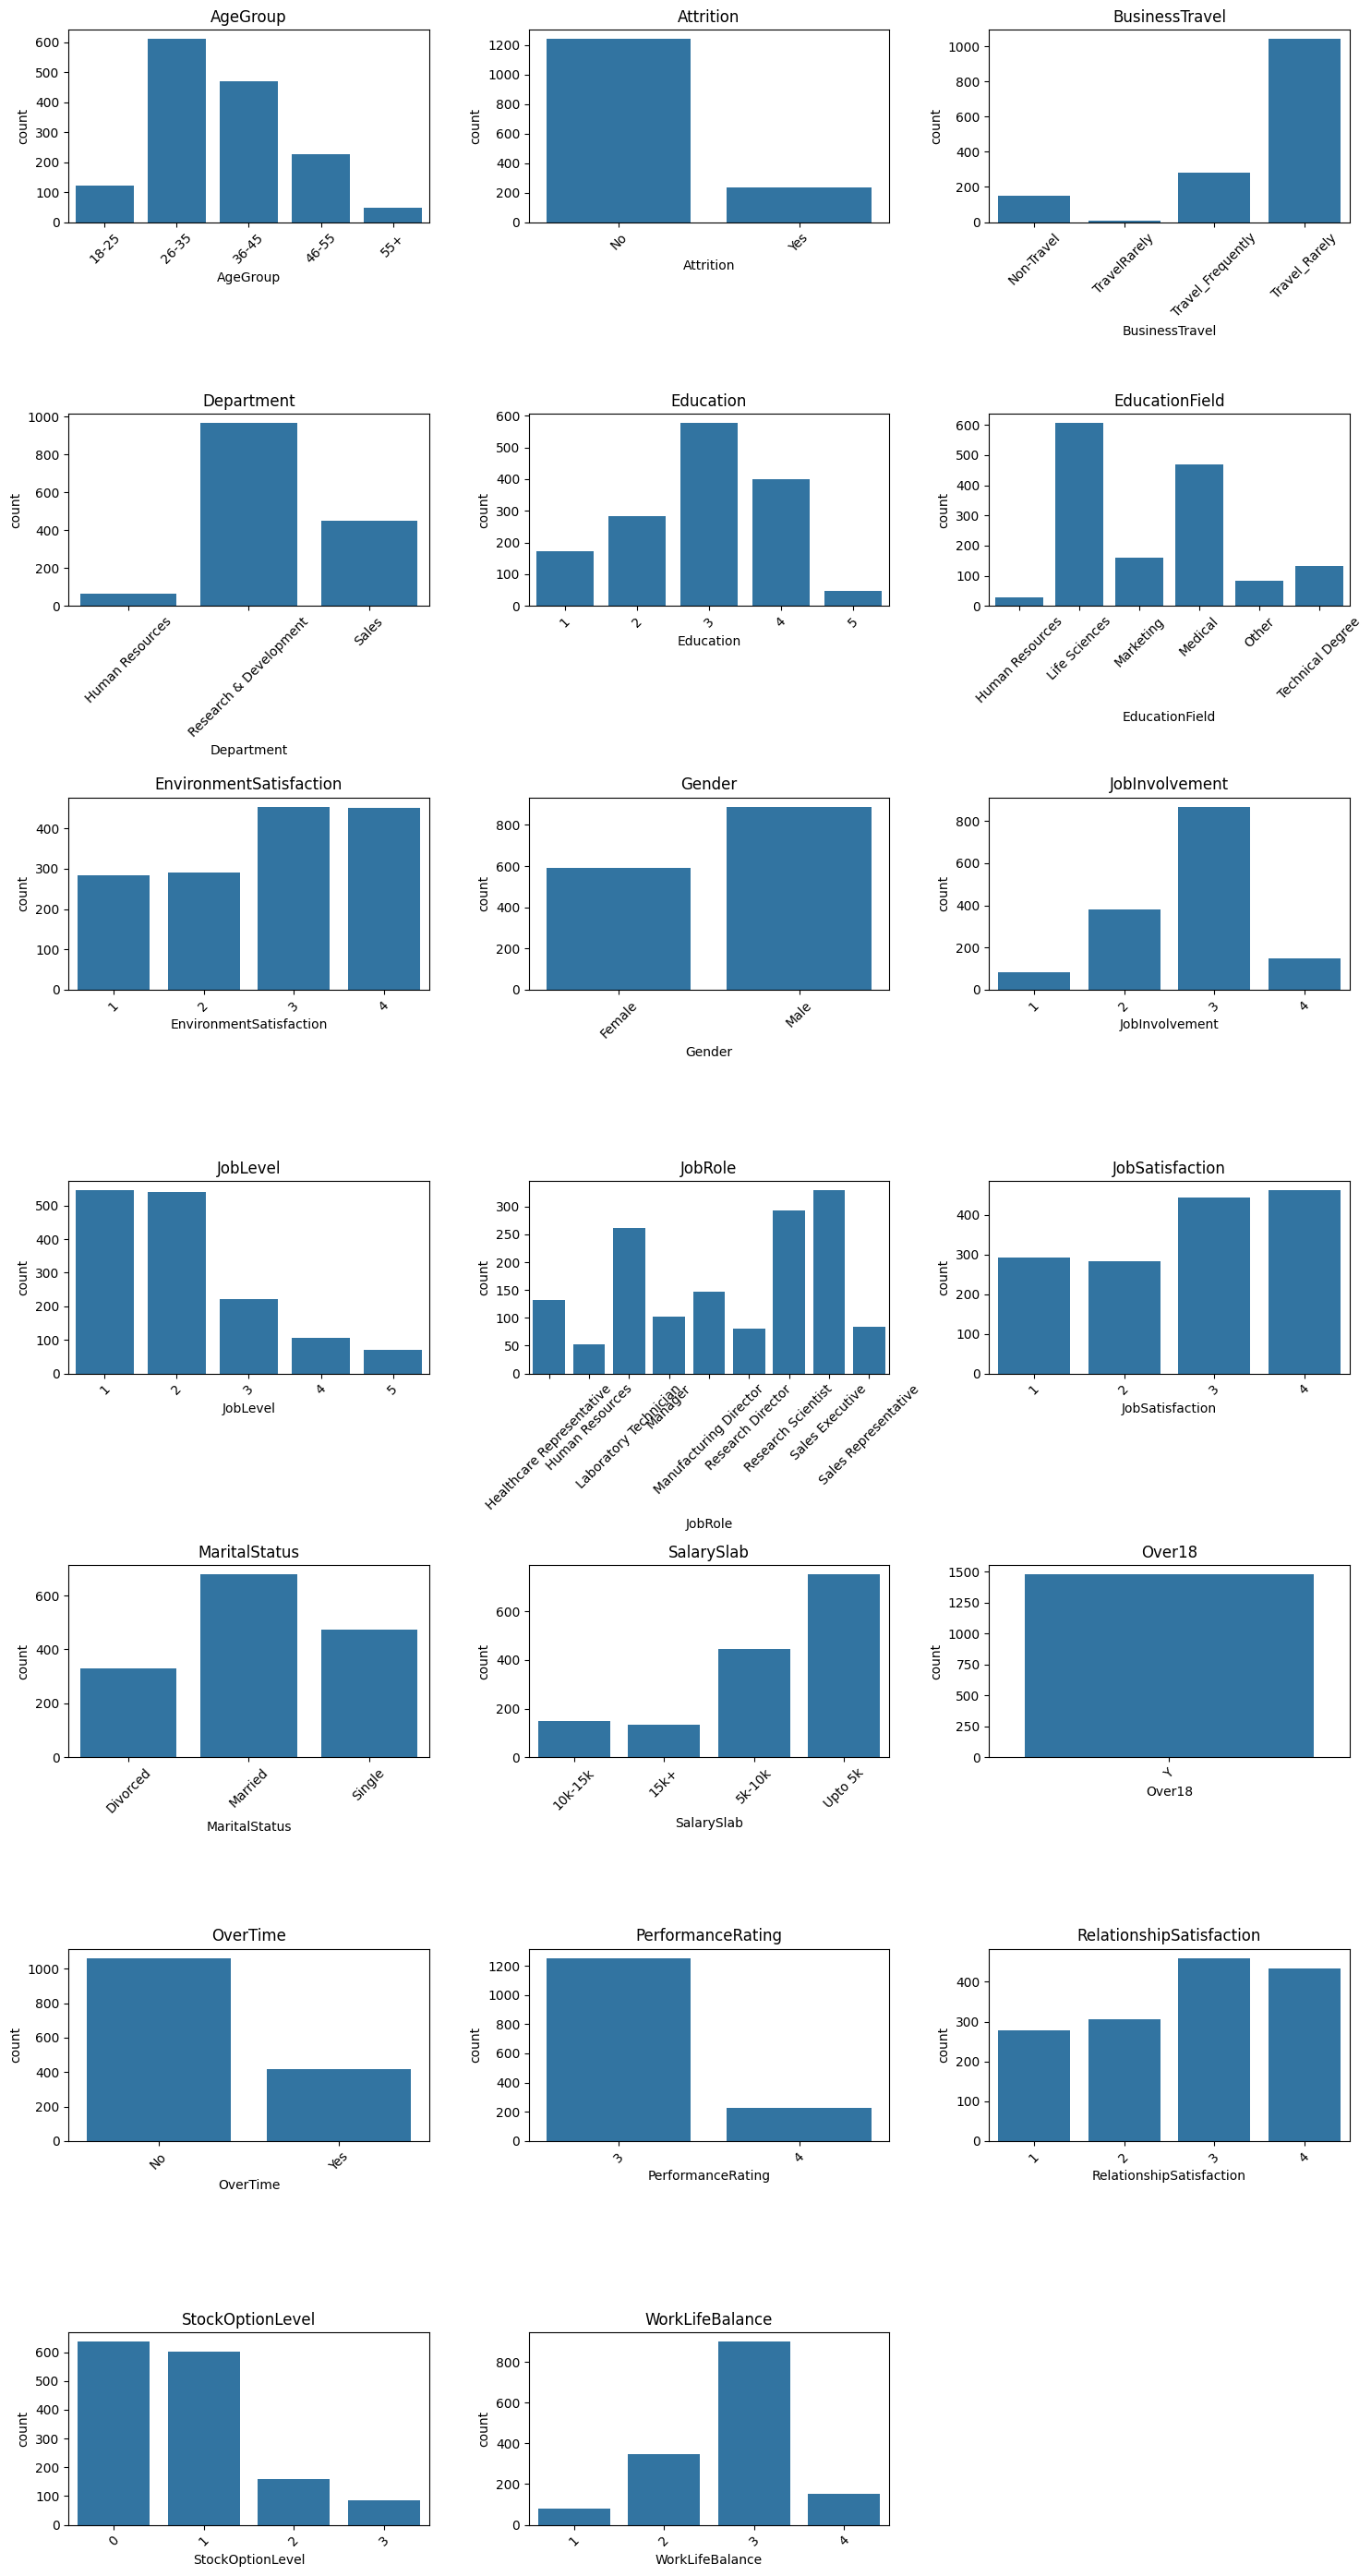

In [10]:
category_cols = metadata_df.loc[
    (metadata_df['Category Type'].isin(['Categorical (nominal)', 'Categorical (ordinal)'])) &
    (metadata_df['Role'] != 'ID'), 'Column Name'
].tolist()

n = len(category_cols)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for i, f in enumerate(category_cols):
    sns.countplot(x=f, data=df, ax=axes[i], order=sorted(df[f].unique()))
    axes[i].set_title(f'{f}')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 2.2 Continuos Variables

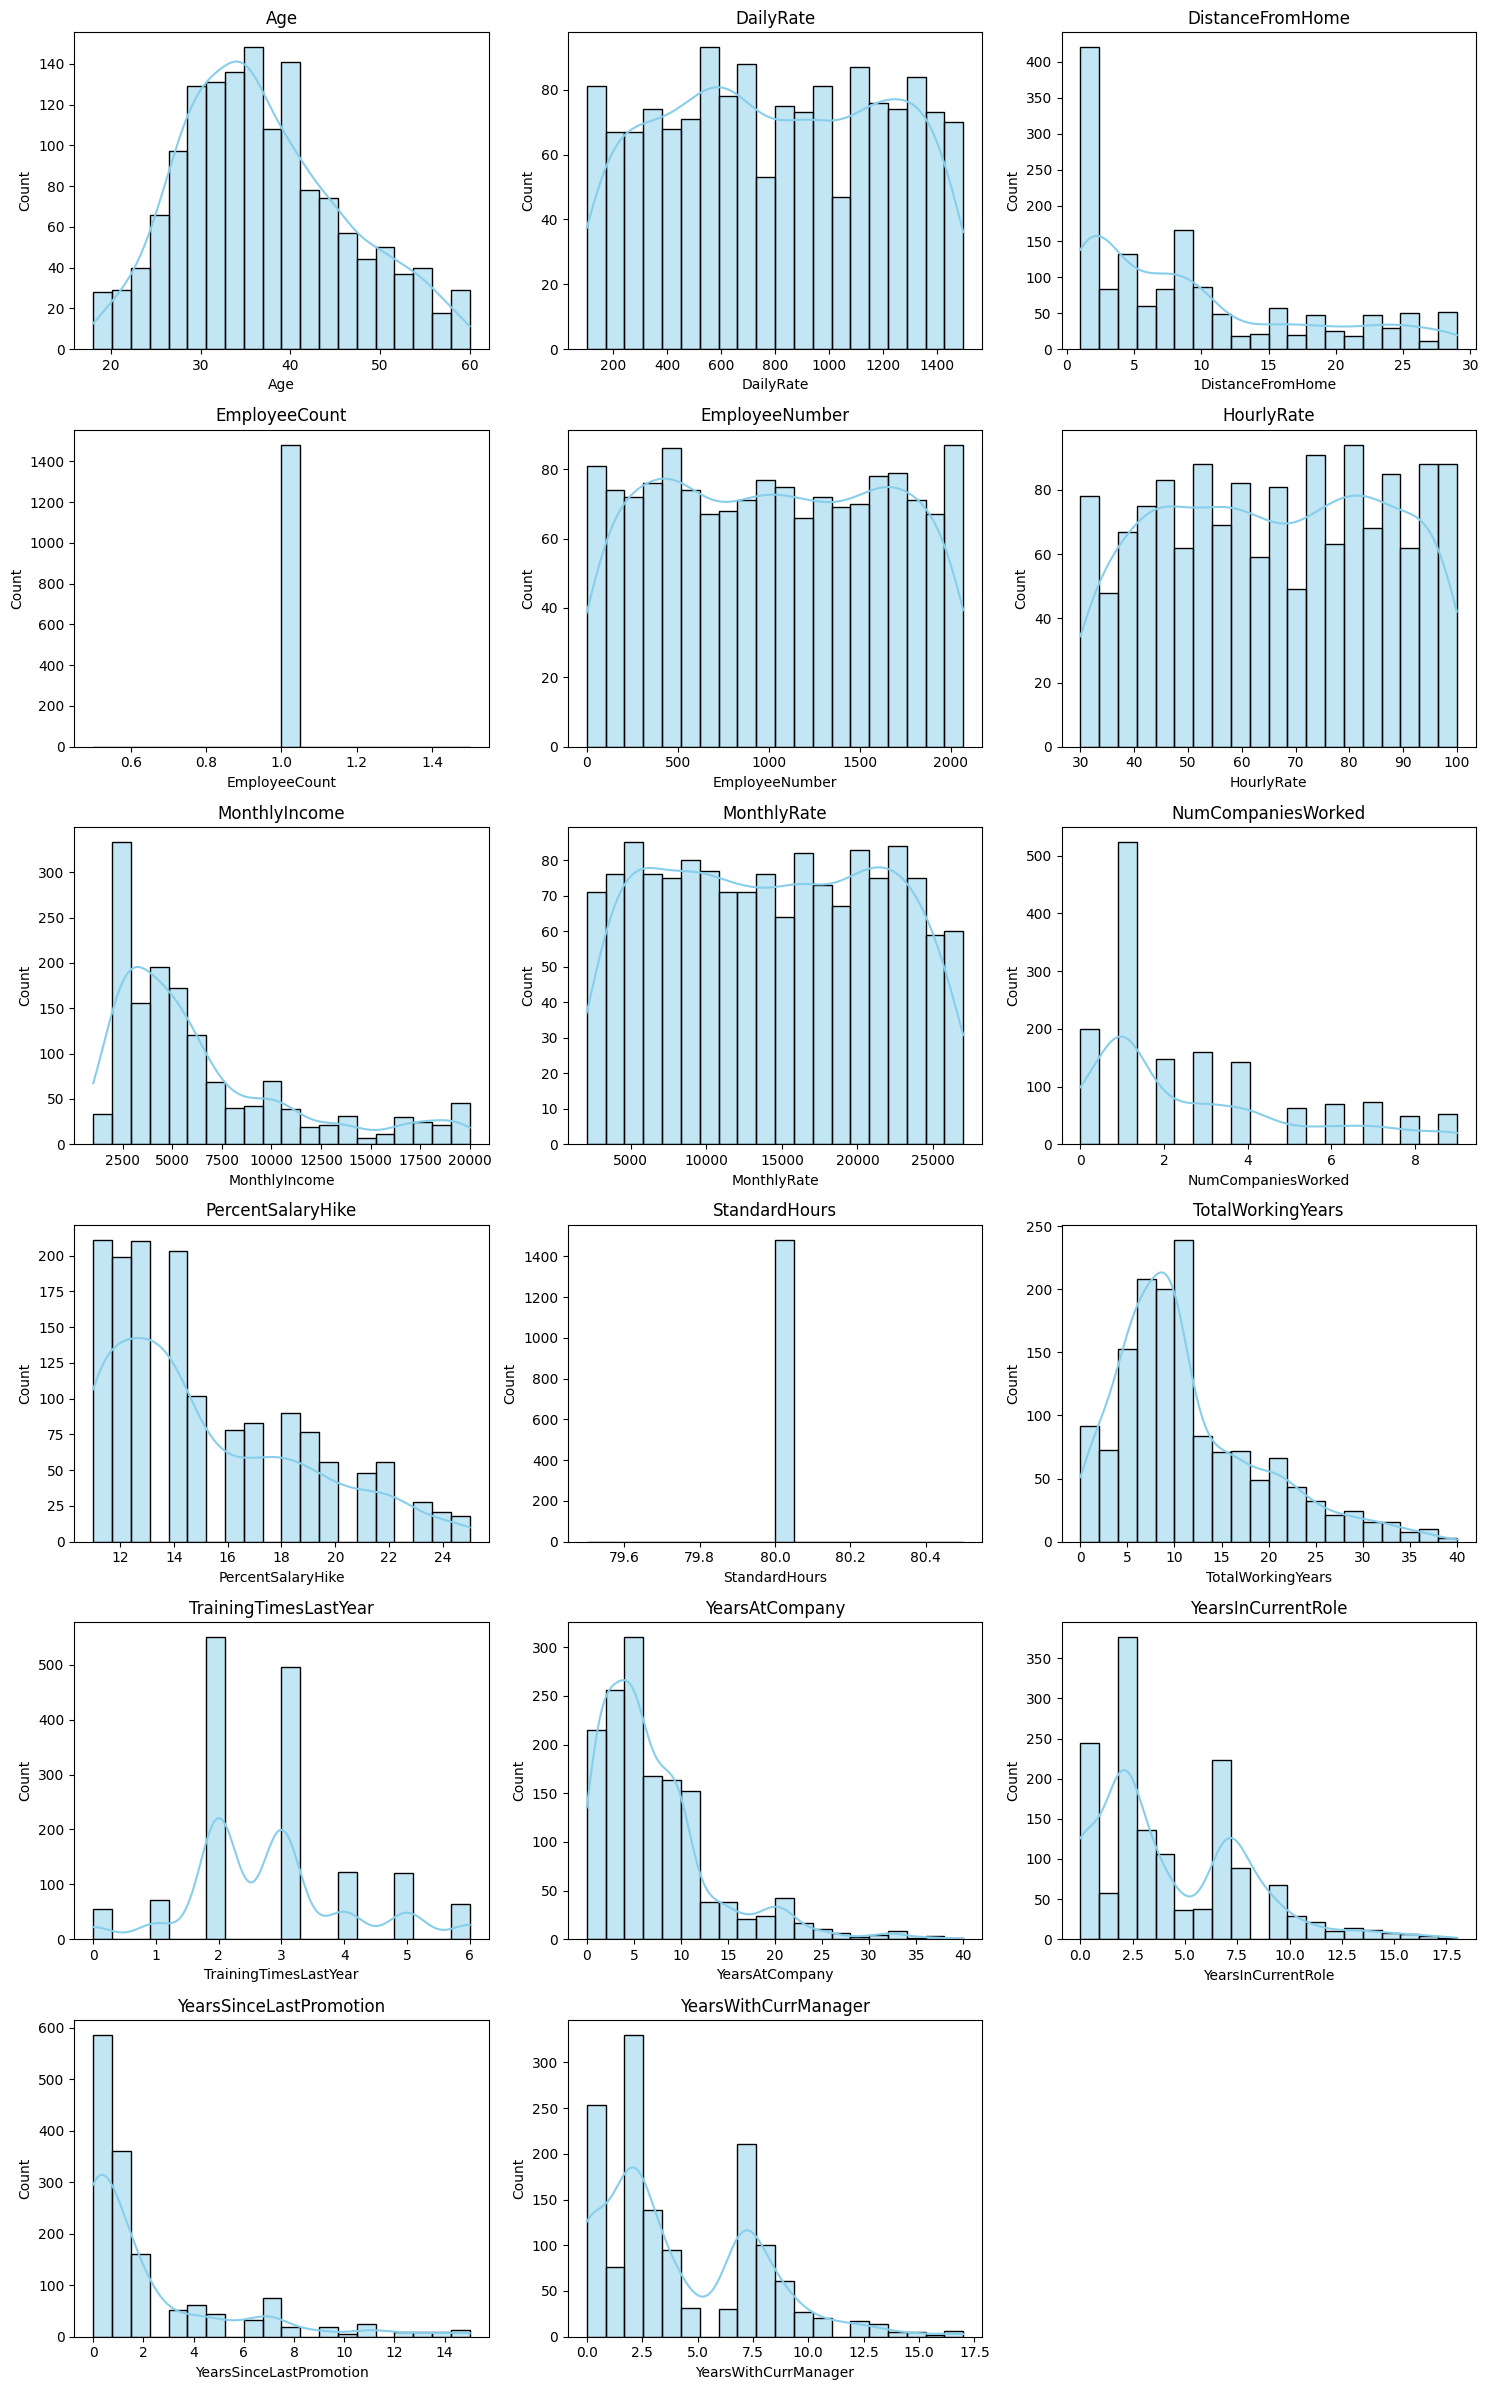

In [11]:
continuous_cols = metadata_df.loc[
    (metadata_df['Category Type']=='Continuous') &
    (metadata_df['Role'] != 'ID/Constant'), 'Column Name'
].tolist()

n = len(continuous_cols)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for i, f in enumerate(continuous_cols):
    sns.histplot(df[f], kde=True, bins=20, color='skyblue', ax=axes[i])
    axes[i].set_title(f'{f}')
    axes[i].set_xlabel(f)
    axes[i].set_ylabel('Count')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 3. Data preparation

## 3.1 Handling ID and Constant Columns

Remove ID columns

In [12]:
id_constant_cols = metadata_df.loc[metadata_df['Role'] == 'ID', 'Column Name'].tolist()

print("Columns to drop (ID):", id_constant_cols)

df_cleaned = df.drop(columns=id_constant_cols)

print("Shape before:", df.shape)
print("Shape after dropping ID:", df_cleaned.shape)

Columns to drop (ID): ['EmpID', 'EmployeeNumber']
Shape before: (1480, 38)
Shape after dropping ID: (1480, 36)


Remove constant columns

In [13]:
constant_cols = [col for col in df_cleaned.columns if df_cleaned[col].nunique() == 1]

print("Columns with all same values (to drop):", constant_cols)
df_cleaned = df_cleaned.drop(columns=constant_cols)
print("Shape after dropping constant columns:", df_cleaned.shape)

Columns with all same values (to drop): ['EmployeeCount', 'Over18', 'StandardHours']
Shape after dropping constant columns: (1480, 33)


## 3.2 Handling missing values

Handle missing values for category columns

In [14]:
categorical_cols = [col for col in metadata_df.loc[
    metadata_df['Category Type'].isin(['Categorical (nominal)', 'Categorical (ordinal)']),
    'Column Name'
].tolist() if col in df_cleaned.columns]

continuous_cols = [col for col in metadata_df.loc[
    metadata_df['Category Type']=='Continuous', 'Column Name'
].tolist() if col in df_cleaned.columns]

for col in categorical_cols:
    if df_cleaned[col].isnull().sum() > 0:
        mode_value = df_cleaned[col].mode()[0]
        df_cleaned[col].fillna(mode_value, inplace=True)
        print(f'Filled missing in {col} with mode: {mode_value}')

for col in continuous_cols:
    if df_cleaned[col].isnull().sum() > 0:
        median_value = df_cleaned[col].median()
        df_cleaned[col].fillna(median_value, inplace=True)
        print(f'Filled missing in {col} with median: {median_value}')

print("Missing values remaining:\n", df_cleaned.isnull().sum())

Filled missing in YearsWithCurrManager with median: 3.0
Missing values remaining:
 Age                         0
AgeGroup                    0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
SalarySlab                  0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRol

/tmp/ipython-input-754858407.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned[col].fillna(median_value, inplace=True)


Handle missing values for continuous columns

## 3.3 Type casting

In [15]:
# Continuous → float
for col in continuous_cols:
    df_cleaned[col] = df_cleaned[col].astype(float)

# Categorical → category
for col in categorical_cols:
    df_cleaned[col] = df_cleaned[col].astype('category')
print(df_cleaned.dtypes)


Age                          float64
AgeGroup                    category
Attrition                   category
BusinessTravel              category
DailyRate                    float64
Department                  category
DistanceFromHome             float64
Education                   category
EducationField              category
EnvironmentSatisfaction     category
Gender                      category
HourlyRate                   float64
JobInvolvement              category
JobLevel                    category
JobRole                     category
JobSatisfaction             category
MaritalStatus               category
MonthlyIncome                float64
SalarySlab                  category
MonthlyRate                  float64
NumCompaniesWorked           float64
OverTime                    category
PercentSalaryHike            float64
PerformanceRating           category
RelationshipSatisfaction    category
StockOptionLevel            category
TotalWorkingYears            float64
T

In [16]:
categorical_nominal_cols = metadata_df.loc[
    (metadata_df['Category Type']=='Categorical (nominal)') &
    (metadata_df['Column Name'].isin(df_cleaned.columns)),
    'Column Name'
].tolist()

categorical_ordinal_cols = metadata_df.loc[
    (metadata_df['Category Type']=='Categorical (ordinal)') &
    (metadata_df['Column Name'].isin(df_cleaned.columns)),
    'Column Name'
].tolist()

ordinal_encoder = OrdinalEncoder()
if categorical_ordinal_cols:
    df_cleaned[categorical_ordinal_cols] = ordinal_encoder.fit_transform(df_cleaned[categorical_ordinal_cols])

df_final = pd.get_dummies(df_cleaned, columns=categorical_nominal_cols, drop_first=True)
df_final['Attrition'] = df_final['Attrition_Yes']
df_final.drop(columns=['Attrition_Yes'], inplace=True)

print("Columns after encoding:")
print(df_final.columns)

Columns after encoding:
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'AgeGroup_26-35',
       'AgeGroup_36-45', 'AgeGroup_46-55', 'AgeGroup_55+',
       'BusinessTravel_TravelRarely', 'BusinessTravel_Travel_Frequently',
       'BusinessTravel_Travel_Rarely', 'Department_Research & Development',
       'Department_Sales', 'EducationField_Life Sciences',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Other', 'EducationField_Technical Degree',
       'Gender_Male', 'JobRole_Human Resources',
       'JobRole_Labora

## 3.4 Multi-Feature Visualizations

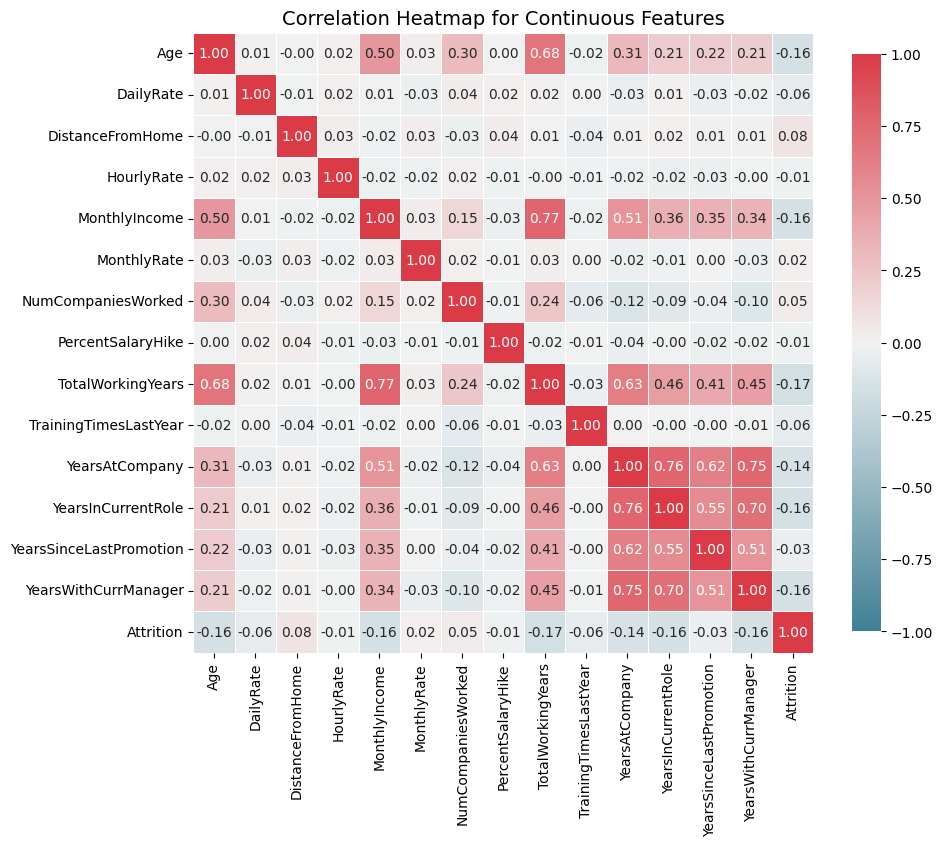

In [17]:
def corr_heatmap_continuous(df, cols, target_col, figsize=(10,10)):
    cols_to_corr = cols.copy()
    if target_col and target_col in df.columns:
        cols_to_corr.append(target_col)

    correlations = df[cols_to_corr].corr()
    cmap = sns.diverging_palette(220, 10, as_cmap=True)

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        correlations,
        cmap=cmap,
        vmax=1.0,
        vmin=-1.0,
        center=0,
        fmt='.2f',
        square=True,
        linewidths=.5,
        annot=True,
        cbar_kws={"shrink": .75}
    )
    plt.title("Correlation Heatmap for Continuous Features", fontsize=14)
    plt.show()
corr_heatmap_continuous(df_final, continuous_cols, target_col='Attrition')


# 4.Model Training and Evaluation

## 4.1 Train/Test Split

In [18]:
X = df_final.drop(columns=['Attrition'])
y = df_final['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

print("Train target distribution:\n", y_train.value_counts(normalize=True))
print("Test target distribution:\n", y_test.value_counts(normalize=True))


Train shape: (1036, 52) (1036,)
Test shape: (444, 52) (444,)
Train target distribution:
 Attrition
False    0.838803
True     0.161197
Name: proportion, dtype: float64
Test target distribution:
 Attrition
False    0.84009
True     0.15991
Name: proportion, dtype: float64


## 4.2 Train model LightGBM

In [19]:
!pip install lightgbm

In [20]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    class_weight='balanced',
    random_state=42
)

lgb_model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 167, number of negative: 869
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000653 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1155
[LightGBM] [Info] Number of data points in the train set: 1036, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


LGBMClassifier(class_weight='balanced', learning_rate=0.03, n_estimators=500,
               random_state=42)

In [21]:
y_pred = lgb_model.predict(X_test)
y_proba = lgb_model.predict_proba(X_test)[:, 1]

## 4.3 Evaluation

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.90      0.95      0.93       373
        True       0.65      0.44      0.52        71

    accuracy                           0.87       444
   macro avg       0.77      0.70      0.72       444
weighted avg       0.86      0.87      0.86       444



In [23]:
auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC =", auc)

ROC-AUC = 0.8337424007854095
